In [12]:
!pip install -U ultralytics

In [13]:
import ultralytics
print(f"Ultralytics version: {ultralytics.__version__}")
import torch
print(f"Torch version: {torch.__version__}")
import cv2
import numpy as np
from ultralytics import YOLO
import os
from PIL import Image
from torchvision import transforms
from IPython.display import display, clear_output 
from collections import defaultdict

import cv2
import numpy as np
from collections import defaultdict
from PIL import Image
from IPython.display import display, clear_output

Ultralytics version: 8.4.32
Torch version: 2.5.1


In [14]:

print(torch.__version__)
print(torch.version.cuda)
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

device = "cuda" if torch.cuda.is_available() else "cpu"
x = torch.rand(10000,10000).to(device)
print(x.device)

2.5.1
12.4
True
NVIDIA GeForce RTX 3070
cuda:0


In [15]:
!nvidia-smi

Mon Mar 30 23:27:04 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 595.71                 Driver Version: 595.71         CUDA Version: 13.2     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3070      WDDM  |   00000000:01:00.0  On |                  N/A |
|  0%   46C    P8             22W /  220W |    4554MiB /   8192MiB |     84%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

data\traffic.mp4
Detection_dev\model_training\yolo8_v0\main (1).ipynb

In [16]:
model = YOLO('yolo26n.pt')
video_path = r"..\..\..\data\traffic.mp4"
cap = cv2.VideoCapture(video_path)

In [17]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [18]:
import cv2
import numpy as np
from collections import defaultdict
from PIL import Image
from IPython.display import display, clear_output

CONF_THRESHOLD = 0.01
OUTPUT_PATH = 'trajectory.mp4'
VIDEO_FOURCC = 'mp4v'
TRACK_COLOR = (0, 255, 0)
LINE_THICKNESS = 2

class Car:
    def __init__(self, trackId: int):
        self.trackId = trackId
        self.x = 0.0
        self.y = 0.0
        self.w = 0.0
        self.h = 0.0
        self.confidence = 0.0
        self.label = ""
        self.history = []
        self.lastCrop = None

    def update(self, box, confidence, label, frame):
        self.x, self.y, self.w, self.h = box
        self.confidence = confidence
        self.label = label
        self.history.append((float(self.x), float(self.y + self.h / 2)))
        
        x1 = int(self.x - self.w / 2)
        y1 = int(self.y - self.h / 2)
        x2 = int(self.x + self.w / 2)
        y2 = int(self.y + self.h / 2)
        
        crop = frame[max(0, y1):min(frame.shape[0], y2), max(0, x1):min(frame.shape[1], x2)]
        if crop.size > 0:
            self.lastCrop = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)

frameWidth = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
frameHeight = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = int(cap.get(cv2.CAP_PROP_FPS))

fourcc = cv2.VideoWriter_fourcc(*VIDEO_FOURCC)
out = cv2.VideoWriter(OUTPUT_PATH, fourcc, fps, (frameWidth, frameHeight))

carsDict = {}

try:
    while cap.isOpened():
        success, frame = cap.read()
        if not success:
            break

        results = model.track(
            source=frame, 
            conf=CONF_THRESHOLD, 
            persist=True,  
            verbose=False, 
            device=0 if device == 'cuda' else 'cpu'
        )

        annotatedFrame = results[0].plot()

        if results[0].boxes.id is not None:
            boxes = results[0].boxes.xywh.cpu()
            trackIds = results[0].boxes.id.int().cpu().tolist()
            classIndices = results[0].boxes.cls.int().cpu().tolist()
            confidences = results[0].boxes.conf.cpu().tolist()

            for box, trackId, classIdx, conf in zip(boxes, trackIds, classIndices, confidences):
                if trackId not in carsDict:
                    carsDict[trackId] = Car(trackId)
                
                car = carsDict[trackId]
                car.update(box, conf, model.names[classIdx], frame)
                
                points = np.array(car.history).astype(np.int32).reshape((-1, 1, 2))
                cv2.polylines(annotatedFrame, [points], isClosed=False, color=TRACK_COLOR, thickness=LINE_THICKNESS)

        out.write(annotatedFrame)
        annotatedFrameRgb = cv2.cvtColor(annotatedFrame, cv2.COLOR_BGR2RGB)
        img = Image.fromarray(annotatedFrameRgb)

        clear_output(wait=True)
        display(img)

except KeyboardInterrupt:
    pass

finally:
    cap.release()
    out.release()
    cv2.destroyAllWindows()

for carId, carObj in carsDict.items():
    if carObj.lastCrop is not None:
        print(f"Car ID: {carId} | Label: {carObj.label} | Conf: {carObj.confidence:.2f}")
        display(Image.fromarray(carObj.lastCrop))

error: OpenCV(4.10.0) D:\a\opencv-python\opencv-python\opencv\modules\highgui\src\window.cpp:1295: error: (-2:Unspecified error) The function is not implemented. Rebuild the library with Windows, GTK+ 2.x or Cocoa support. If you are on Ubuntu or Debian, install libgtk2.0-dev and pkg-config, then re-run cmake or configure script in function 'cvDestroyAllWindows'


Car ID: 1 | Label: truck | Conf: 0.31


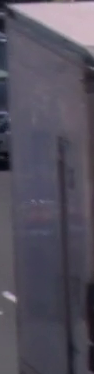

Car ID: 2 | Label: truck | Conf: 0.27


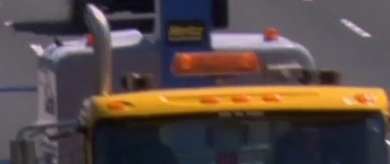

Car ID: 3 | Label: car | Conf: 0.72


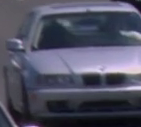

Car ID: 4 | Label: car | Conf: 0.90


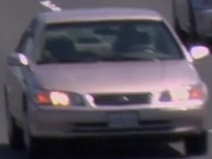

Car ID: 5 | Label: car | Conf: 0.44


Car ID: 6 | Label: car | Conf: 0.34


Car ID: 7 | Label: car | Conf: 0.40


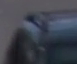

Car ID: 8 | Label: car | Conf: 0.74


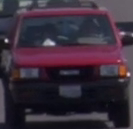

Car ID: 9 | Label: car | Conf: 0.25


Car ID: 10 | Label: car | Conf: 0.39


Car ID: 11 | Label: car | Conf: 0.62


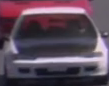

Car ID: 12 | Label: car | Conf: 0.78


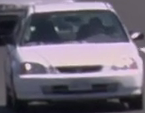

Car ID: 13 | Label: truck | Conf: 0.52


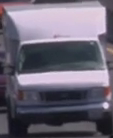

Car ID: 14 | Label: car | Conf: 0.30


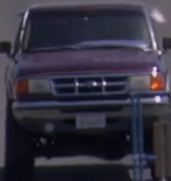

Car ID: 21 | Label: car | Conf: 0.37


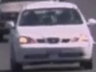

Car ID: 33 | Label: car | Conf: 0.51


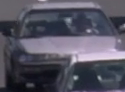

Car ID: 34 | Label: car | Conf: 0.36


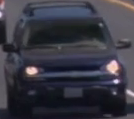

Car ID: 35 | Label: car | Conf: 0.26


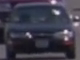

Car ID: 53 | Label: car | Conf: 0.31


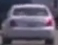

Car ID: 57 | Label: car | Conf: 0.40


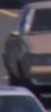

Car ID: 66 | Label: car | Conf: 0.28


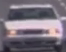

Car ID: 67 | Label: truck | Conf: 0.34


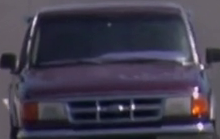

Car ID: 70 | Label: car | Conf: 0.46


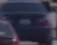

Car ID: 76 | Label: car | Conf: 0.59


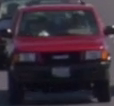

Car ID: 86 | Label: car | Conf: 0.29


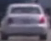

Car ID: 88 | Label: car | Conf: 0.26


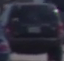

Car ID: 99 | Label: car | Conf: 0.43


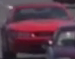

Car ID: 109 | Label: car | Conf: 0.27


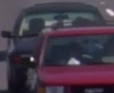

Car ID: 111 | Label: car | Conf: 0.32


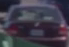

Car ID: 113 | Label: car | Conf: 0.54


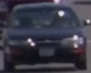

Car ID: 130 | Label: car | Conf: 0.40


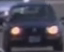

In [19]:
for carId, carObj in carsDict.items():
    if carObj.lastCrop is not None:
        print(f"Car ID: {carId} | Label: {carObj.label} | Conf: {carObj.confidence:.2f}")
        display(Image.fromarray(carObj.lastCrop))